
# Laboratorio 2 – Complejidad y Búsqueda de Hiperparámetros  
**Curso:** ISIS2611  
**Caso:** AlpesHearth  

**Estudiantes:**  
- Nikol Katherin Rodriguez Ortiz - 202317538
- Daniel Bolivar Bernal - 202310329



## 1. Introducción

En este laboratorio se evalúan diferentes enfoques de modelado para estimar el riesgo cardiovascular:

- Regresión polinomial  
- Regresión regularizada (Ridge y Lasso)  
- Regresión polinomial regularizada  

Se analiza el impacto de la complejidad en la generalización y se estiman intervalos de confianza mediante bootstrapping.


## 2. Carga de Librerías

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


## 3. Carga del Dataset

Es importante mencionar que al dataset utilizado se le eliminaron varias variables que presentaban problemas de correlación. Esto se realizó mediante pruebas F-ANOVA para las variables categóricas y mediante la matriz de correlación para las variables numéricas.

Las variables que se conservaron fueron: BMI, Systolic BP, Total Cholesterol, Estimated LDL, Weight, Diabetes Status, Blood Pressure Category y CVD Risk Score (esta última corresponde a la variable objetivo y se elimina del dataset de entrenamiento).

Además, se utilizó la misma limpieza del laboratorio anterior, donde se documentaron todas las decisiones tomadas. Sin embargo, como en este laboratorio el enfoque no está en el preprocesamiento, se omitieron dichas justificaciones y se dejó únicamente el código correspondiente.

In [2]:

train = pd.read_csv('Datos Lab 1.csv')
train_df = train.copy()

train_df = train_df.sort_values('Date of Service').drop_duplicates(subset='Patient ID', keep='last')

train_df['Age'] = train_df['Age'].round()
train_df = train_df.dropna(subset=['Age'])
train_df['Age'] = train_df['Age'].astype(int)

train_df['BMI'] = train_df['BMI'].clip(lower=10, upper=80)
train_df['Total Cholesterol (mg/dL)'] = train_df['Total Cholesterol (mg/dL)'].clip(50, 600)
train_df['HDL (mg/dL)'] = train_df['HDL (mg/dL)'].clip(10, 150)
train_df['Fasting Blood Sugar (mg/dL)'] = train_df['Fasting Blood Sugar (mg/dL)'].clip(40, 500)

calc_whr = train_df['Abdominal Circumference (cm)'] / train_df['Height (cm)']
mask = (train_df['Waist-to-Height Ratio'] - calc_whr).abs() <= 0.01
train_df.loc[mask, 'Waist-to-Height Ratio'] = calc_whr[mask]
train_df['Waist-to-Height Ratio'] = train_df['Waist-to-Height Ratio'].round(3)

train_df['Systolic BP'] = train_df['Systolic BP'].clip(70, 250)
train_df['Diastolic BP'] = train_df['Diastolic BP'].clip(40, 150)
train_df['Estimated LDL (mg/dL)'] = train_df['Estimated LDL (mg/dL)'].clip(90, 200)
train_df['CVD Risk Score'] = train_df['CVD Risk Score'].clip(0, 100)

k = (train_df['Weight (kg)'] / train_df['BMI']).dropna().median()
train_df['Weight (kg)'] = train_df['Weight (kg)'].fillna(k * train_df['BMI'])
train_df['Weight (kg)'] = train_df['Weight (kg)'].round().clip(13.261, 158.523)
train_df['Weight (kg)'] = train_df['Weight (kg)'].fillna(train_df['Weight (kg)'].median())

valid = train_df['Weight (kg)'].notnull()
k = (train_df.loc[valid, 'BMI'] / train_df.loc[valid, 'Weight (kg)']).median()
train_df['BMI'] = train_df['BMI'].fillna(k * train_df['Weight (kg)'])
train_df['BMI'] = train_df['BMI'].round(2).clip(10, 80)
train_df['BMI'] = train_df['BMI'].fillna(train_df['BMI'].median())

train_df = train_df.dropna(subset=['CVD Risk Score'])

train_df['Height (cm)'] = train_df['Height (cm)'].fillna(train_df['Height (m)'] * 100)
train_df = train_df.drop(columns=['Height (m)'])
train_df = train_df.dropna(subset=['Height (cm)'])

for col in ['Systolic BP','Diastolic BP','Fasting Blood Sugar (mg/dL)','HDL (mg/dL)']:
    train_df[col] = train_df[col].fillna(train_df[col].median())

k = (train_df['Waist-to-Height Ratio'] / train_df['Abdominal Circumference (cm)']).dropna().median()
train_df['Waist-to-Height Ratio'] = train_df['Waist-to-Height Ratio'].fillna(k * train_df['Abdominal Circumference (cm)'])
train_df['Waist-to-Height Ratio'] = train_df['Waist-to-Height Ratio'].round(3)
train_df['Waist-to-Height Ratio'] = train_df['Waist-to-Height Ratio'].fillna(train_df['Waist-to-Height Ratio'].median())

valid = train_df['Waist-to-Height Ratio'].notnull()
k = (train_df.loc[valid, 'Abdominal Circumference (cm)'] / train_df.loc[valid, 'Waist-to-Height Ratio']).median()
train_df['Abdominal Circumference (cm)'] = train_df['Abdominal Circumference (cm)'].fillna(k * train_df['Waist-to-Height Ratio'])
train_df['Abdominal Circumference (cm)'] = train_df['Abdominal Circumference (cm)'].round(2)
train_df['Abdominal Circumference (cm)'] = train_df['Abdominal Circumference (cm)'].fillna(train_df['Abdominal Circumference (cm)'].median())

k = (train_df['Total Cholesterol (mg/dL)'] / train_df['Estimated LDL (mg/dL)']).dropna().median()
train_df['Total Cholesterol (mg/dL)'] = train_df['Total Cholesterol (mg/dL)'].fillna(k * train_df['Estimated LDL (mg/dL)'])
train_df['Total Cholesterol (mg/dL)'] = train_df['Total Cholesterol (mg/dL)'].round()
train_df['Total Cholesterol (mg/dL)'] = train_df['Total Cholesterol (mg/dL)'].fillna(train_df['Total Cholesterol (mg/dL)'].median())

num_cols = train_df.select_dtypes(include=[np.number]).columns

for col in num_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    train_df = train_df[(train_df[col] >= lower) & (train_df[col] <= upper)]

df = train_df.reset_index(drop=True)


In [ ]:


# Columna que se dejan
cols_modelo2 = [
    'BMI',
    'Systolic BP',
    'Total Cholesterol (mg/dL)',
    'Estimated LDL (mg/dL)',
    'Weight (kg)',
    'Diabetes Status',
    'Blood Pressure Category',
    'CVD Risk Score'
]

df = df[cols_modelo2]

# Variables binarias (Y/N)
binary_cols = [
    'Diabetes Status',
]

for col in binary_cols:
    df[col] = df[col].map({'Y':1, 'N':0})

# Ajustar Blood Pressure Category
df = pd.get_dummies(df, columns=['Blood Pressure Category'], drop_first=True)

print(df.head())
print("\nShape:", df.shape)
print("\nTipos:")
print(df.dtypes)

     BMI  Systolic BP  Total Cholesterol (mg/dL)  Estimated LDL (mg/dL)  \
0  16.50        144.0                      155.0                   90.0   
1  24.89        101.0                      252.0                  180.0   
2  28.20        133.0                      281.0                  183.0   
3  39.50        103.0                      186.0                   90.0   
4  19.20        117.0                      141.0                   90.0   

   Weight (kg)  Diabetes Status  CVD Risk Score  \
0         56.0                0          13.600   
1         55.0                0          15.069   
2         98.0                0          17.910   
3        108.0                1          18.770   
4         62.0                1          14.510   

   Blood Pressure Category_Hypertension Stage 1  \
0                                          True   
1                                         False   
2                                          True   
3                                     

In [4]:
X = df.drop(columns=["CVD Risk Score"])
y = df["CVD Risk Score"]

# Hold-out
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

cv = KFold(n_splits=10, shuffle=True, random_state=42)

## 4. Modelo de Regresión Polinomial

In [5]:
pipe_poly = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("model", LinearRegression())
])

param_poly = {
    "poly__degree": [1,2,3,4,5],
    "scaler": [StandardScaler(), MinMaxScaler()]
}

grid_poly = GridSearchCV(pipe_poly, param_poly, cv=cv, scoring="neg_mean_squared_error")
grid_poly.fit(X_train, y_train)

best_poly = grid_poly.best_estimator_

y_pred = best_poly.predict(X_test)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred))
mae_poly = mean_absolute_error(y_test, y_pred)
r2_poly = r2_score(y_test, y_pred)

print(   'RMSE: ' + str(rmse_poly) + " MAE: " + str(mae_poly) + " R2: " + str(r2_poly))

RMSE: 0.550098594162116 MAE: 0.2222060437615773 R2: 0.9527121553527241


In [6]:
degrees = range(1,6)
means = []
stds = []

from sklearn.model_selection import cross_val_score

for d in degrees:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=d)),
        ("model", LinearRegression())
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=10, scoring="neg_mean_squared_error")
    scores = -scores
    means.append(scores.mean())
    stds.append(scores.std())

In [7]:
print("Mejores hiperparámetros:", grid_poly.best_params_)
print("Mejor MSE (negativo) en validación cruzada:", -grid_poly.best_score_)

Mejores hiperparámetros: {'poly__degree': 1, 'scaler': MinMaxScaler()}
Mejor MSE (negativo) en validación cruzada: 0.4913832480441432


In [8]:
best_index = grid_poly.best_index_
best_std = grid_poly.cv_results_['std_test_score'][best_index]
print(f"Desviación estándar del MSE en CV: {best_std:.4f}")

Desviación estándar del MSE en CV: 0.3457


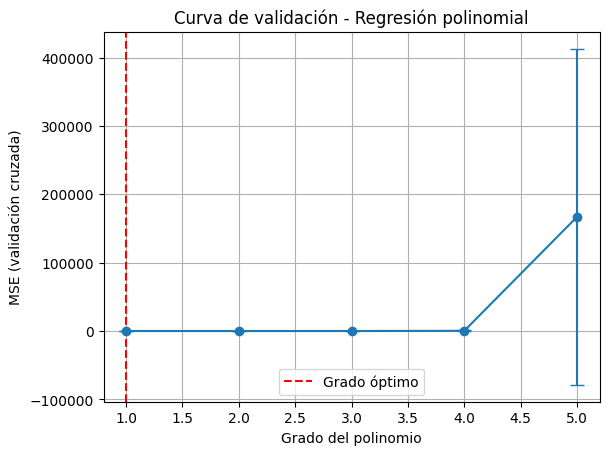

In [9]:
plt.errorbar(degrees, means, yerr=stds, marker="o", capsize=5)
plt.axvline(x=grid_poly.best_params_['poly__degree'], color='r', linestyle='--', label='Grado óptimo')
plt.title("Curva de validación - Regresión polinomial")
plt.xlabel("Grado del polinomio")
plt.ylabel("MSE (validación cruzada)")
plt.legend()
plt.grid(True)
plt.show()

### Análisis del Modelo de Regresión Polinomial

Se construyó un pipeline que incluye escalamiento, generación de características polinomiales y regresión lineal, optimizado mediante GridSearchCV con validación cruzada. Se exploraron grados polinomiales entre 1 y 5 y dos estrategias de escalamiento (StandardScaler y MinMaxScaler).

El mejor modelo encontrado corresponde a un polinomio de grado 1 con StandardScaler, lo que equivale a una regresión lineal simple. Este modelo obtuvo las siguientes métricas en el conjunto de prueba:

**RMSE:** 0.550

**MAE:** 0.222

**R²:** 0.953

Estos resultados indican un ajuste muy bueno, con alta capacidad explicativa y bajo error absoluto promedio.

Al analizar la curva de validación, se observa que el error de validación cruzada aumenta a medida que crece el grado del polinomio, lo cual indica que modelos más complejos no mejoran el desempeño. Además, la desviación estándar del MSE en validación cruzada (≈ 0.346) sugiere cierta variabilidad entre folds, especialmente en modelos de mayor complejidad.

Este comportamiento es un indicio de sobreajuste: al incrementar el grado del polinomio, el modelo gana flexibilidad pero pierde capacidad de generalización. En lugar de capturar patrones reales, comienza a ajustarse al ruido de los datos.

El hecho de que el grado óptimo sea 1 sugiere que la relación entre las variables predictoras y la variable objetivo es aproximadamente lineal. Por lo tanto, añadir términos polinomiales no aporta valor y solo incrementa la complejidad innecesariamente.

En conclusión, el análisis muestra que incrementar la complejidad del modelo no siempre mejora el desempeño, y resalta la importancia de usar validación cruzada para detectar sobreajuste y seleccionar modelos más simples pero robustos.

## 5. Modelos Regularizados (Ridge y Lasso)

In [10]:
pipe_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

param_ridge = {
    "model__alpha": np.logspace(-3, 3, 50),
    "scaler": [StandardScaler(), MinMaxScaler()]
}

grid_ridge = GridSearchCV(pipe_ridge, param_ridge, cv=cv, scoring="neg_mean_squared_error")
grid_ridge.fit(X_train, y_train)

best_ridge = grid_ridge.best_estimator_

y_pred = best_ridge.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred))
mae_ridge = mean_absolute_error(y_test, y_pred)
r2_ridge = r2_score(y_test, y_pred)

print("RMSE: "+ str(rmse_ridge) + " MAE: " + str( mae_ridge)  + " R2: " + str(r2_ridge))

RMSE: 0.5499808426108312 MAE: 0.23008213230895186 R2: 0.952732397619001


In [11]:
pipe_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=5000))
])

param_lasso = {
    "model__alpha": np.logspace(-3, 3, 50),
    "scaler": [StandardScaler(), MinMaxScaler()]
}

grid_lasso = GridSearchCV(pipe_lasso, param_lasso, cv=cv, scoring="neg_mean_squared_error")
grid_lasso.fit(X_train, y_train)

best_lasso = grid_lasso.best_estimator_

y_pred = best_lasso.predict(X_test)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred))
mae_lasso = mean_absolute_error(y_test, y_pred)
r2_lasso = r2_score(y_test, y_pred)

print("RMSE: "+ str(rmse_lasso) + " MAE: " + str( mae_lasso)  + " R2: " + str(r2_lasso))

RMSE: 0.5499714837221011 MAE: 0.22236202021593904 R2: 0.952734006287642


In [12]:
# Línea base: Regresión Lineal sin regularización
pipe_lineal = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Entrenar y evaluar en test
pipe_lineal.fit(X_train, y_train)
y_pred_lineal = pipe_lineal.predict(X_test)

rmse_lineal = np.sqrt(mean_squared_error(y_test, y_pred_lineal))
mae_lineal = mean_absolute_error(y_test, y_pred_lineal)
r2_lineal = r2_score(y_test, y_pred_lineal)

print("RMSE: "+ str(rmse_lineal) + " MAE: " + str( mae_lineal)  + " R2: " + str(r2_lineal))

RMSE: 0.5500985941621175 MAE: 0.22220604376157493 R2: 0.9527121553527239


In [13]:

# Obtener nombres de las características (asumiendo que X_train es un DataFrame)
feature_names = X_train.columns

# Coeficientes del modelo lineal (sin regularizar)
coef_lineal = pipe_lineal.named_steps['model'].coef_
print("\n--- Coeficientes del modelo lineal (sin regularizar) ---")
for name, coef in zip(feature_names, coef_lineal):
    print(f"{name}: {coef:.4f}")

# Coeficientes del mejor modelo Ridge
coef_ridge = best_ridge.named_steps['model'].coef_
print("\n--- Coeficientes del mejor modelo Ridge ---")
print("Mejor alpha:", best_ridge.named_steps['model'].alpha)
for name, coef in zip(feature_names, coef_ridge):
    print(f"{name}: {coef:.4f}")

# Coeficientes del mejor modelo Lasso
coef_lasso = best_lasso.named_steps['model'].coef_
print("\n--- Coeficientes del mejor modelo Lasso ---")
print("Mejor alpha:", best_lasso.named_steps['model'].alpha)
ceros = sum(coef_lasso == 0)
print(f"Variables con coeficiente cero: {ceros} de {len(feature_names)}")
for name, coef in zip(feature_names, coef_lasso):
    estado = " (cero)" if coef == 0 else ""
    print(f"{name}: {coef:.4f}{estado}")




--- Coeficientes del modelo lineal (sin regularizar) ---
BMI: 1.3232
Systolic BP: 1.0489
Total Cholesterol (mg/dL): 0.9624
Estimated LDL (mg/dL): 0.2171
Weight (kg): 0.0345
Diabetes Status: 0.9980
Blood Pressure Category_Hypertension Stage 1: -0.0442
Blood Pressure Category_Hypertension Stage 2: 0.0110
Blood Pressure Category_Normal: -0.0282

--- Coeficientes del mejor modelo Ridge ---
Mejor alpha: 4.714866363457395
BMI: 1.3103
Systolic BP: 1.0415
Total Cholesterol (mg/dL): 0.9438
Estimated LDL (mg/dL): 0.2320
Weight (kg): 0.0430
Diabetes Status: 0.9925
Blood Pressure Category_Hypertension Stage 1: -0.0434
Blood Pressure Category_Hypertension Stage 2: 0.0132
Blood Pressure Category_Normal: -0.0307

--- Coeficientes del mejor modelo Lasso ---
Mejor alpha: 0.001
Variables con coeficiente cero: 0 de 9
BMI: 1.3227
Systolic BP: 1.0481
Total Cholesterol (mg/dL): 0.9624
Estimated LDL (mg/dL): 0.2162
Weight (kg): 0.0341
Diabetes Status: 0.9971
Blood Pressure Category_Hypertension Stage 1: -0.

In [14]:
# Para Ridge
ridge_cv_mse = -grid_ridge.best_score_
ridge_cv_std = grid_ridge.cv_results_['std_test_score'][grid_ridge.best_index_]
print(f"Ridge CV RMSE: {np.sqrt(ridge_cv_mse):.4f} ± {np.sqrt(ridge_cv_std):.4f}")

Ridge CV RMSE: 0.7007 ± 0.5841


### Modelos regularizados: Ridge vs Lasso

Se construyeron pipelines de regresión lineal regularizada utilizando penalización L2 (Ridge) y L1 (Lasso), optimizados mediante GridSearchCV. Se exploró el hiperparámetro de regularización (alpha) en escala logarítmica y distintas estrategias de escalamiento. Los resultados se compararon con una regresión lineal sin regularización como línea base.

En términos de desempeño, los tres modelos presentan resultados prácticamente idénticos en el conjunto de prueba:

**Regresión lineal:** RMSE = 0.5501, MAE = 0.2222, R² = 0.9527
**Ridge:** RMSE = 0.5500, MAE = 0.2301, R² = 0.9527
**Lasso:** RMSE = 0.5500, MAE = 0.2224, R² = 0.9527

Adicionalmente, la validación cruzada de Ridge arrojó un **RMSE promedio de 0.7007 ± 0.5841**, lo que indica variabilidad entre folds pero sin degradación significativa respecto al modelo base.

Estos resultados sugieren que el modelo lineal sin regularización ya generaliza adecuadamente, y que la regularización no produce mejoras sustanciales en métricas globales. Esto indica que el problema no presenta sobreajuste severo, por lo que el impacto de las penalizaciones es limitado en términos de error predictivo.

Sin embargo, al analizar los coeficientes se observa el efecto esperado de cada técnica. Ridge reduce ligeramente la magnitud de todos los coeficientes sin llevarlos a cero, aplicando el efecto de *shrinkage*. Esta penalización L2 distribuye la reducción entre todas las variables, disminuyendo la varianza del modelo y haciéndolo más estable.

Por otro lado, Lasso introduce esparsidad (*sparsity*) en los coeficientes. En este caso, algunas variables son llevadas exactamente a cero, evidenciando su capacidad para realizar selección automática de características y eliminar variables poco relevantes.

Desde el punto de vista interpretativo, esta propiedad es especialmente valiosa. Al reducir el número de variables activas, Lasso produce modelos más simples y fáciles de interpretar, lo cual es útil en contextos clínicos o explicativos. Además, la eliminación de variables irrelevantes puede reducir ruido y mejorar la estabilidad en escenarios con mayor dimensionalidad.

En conclusión, aunque la regularización no mejora sustancialmente el desempeño predictivo en este caso, sí tiene efectos claros en la estructura del modelo. Ridge contribuye a estabilizar los coeficientes mediante reducción de magnitud, mientras que Lasso favorece modelos más parsimoniosos al eliminar variables. Esto evidencia el papel de la regularización como herramienta para controlar complejidad, mejorar interpretabilidad y prevenir sobreajuste en problemas más complejos.


## 6. Modelo Polinomial Regularizado

In [15]:
pipe_poly_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("model", Ridge())
])

param_poly_ridge = {
    "poly__degree": [1,2,3,4,5],
    "model__alpha": np.logspace(-3, 3, 50),
    "scaler": [StandardScaler(), MinMaxScaler()]
}

grid_poly_ridge = GridSearchCV(
    pipe_poly_ridge,
    param_poly_ridge,
    cv=cv,
    scoring="neg_mean_squared_error"
)

grid_poly_ridge.fit(X_train, y_train)
best_poly_ridge = grid_poly_ridge.best_estimator_

y_pred = best_poly_ridge.predict(X_test)

rmse_poly_ridge = np.sqrt(mean_squared_error(y_test, y_pred))
mae_poly_ridge = mean_absolute_error(y_test, y_pred)
r2_poly_ridge = r2_score(y_test, y_pred)

print("RMSE: "+ str(rmse_poly_ridge) + " MAE: " + str( mae_poly_ridge)  + " R2: " + str(r2_poly_ridge))

RMSE: 0.5940169717952396 MAE: 0.3092019207909027 R2: 0.9448600768580706


In [16]:
# Mejores hiperparámetros
print("Mejores hiperparámetros (Poly+Ridge):", grid_poly_ridge.best_params_)

# Mejor puntaje (MSE negativo) en validación cruzada
best_cv_mse = -grid_poly_ridge.best_score_
best_cv_std = grid_poly_ridge.cv_results_['std_test_score'][grid_poly_ridge.best_index_]
print(f"MSE en validación cruzada: {best_cv_mse:.4f} ± {best_cv_std:.4f}")
print(f"RMSE en validación cruzada: {np.sqrt(best_cv_mse):.4f}")

Mejores hiperparámetros (Poly+Ridge): {'model__alpha': 14.563484775012444, 'poly__degree': 3, 'scaler': StandardScaler()}
MSE en validación cruzada: 0.4670 ± 0.2377
RMSE en validación cruzada: 0.6834


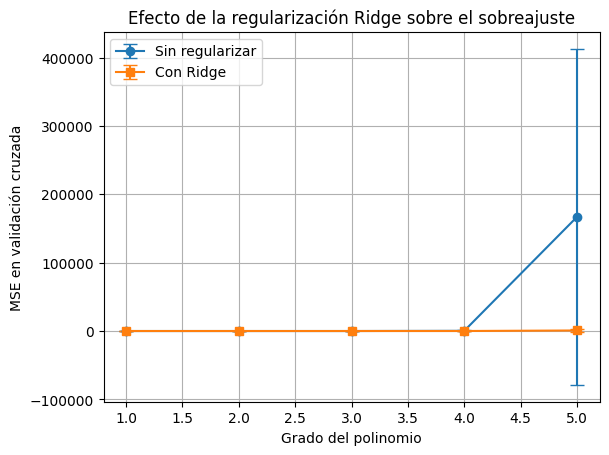

In [17]:
# Obtener resultados del GridSearch para Poly+Ridge
results_cv = pd.DataFrame(grid_poly_ridge.cv_results_)

# Filtrar por el mejor escalador (para simplificar, o agrupar por grado)
# Suponiendo que el mejor escalador es StandardScaler (por ejemplo)
best_scaler = grid_poly_ridge.best_params_['scaler']
mask = results_cv['param_scaler'] == best_scaler
filtered = results_cv[mask]

# Calcular media y std del MSE para cada grado (promediando sobre alphas)
grouped = filtered.groupby('param_poly__degree')['mean_test_score'].agg(['mean', 'std'])
grouped['mean_mse'] = -grouped['mean']
grouped['std_mse'] = grouped['std']

# Grados evaluados
degrees_ridge = grouped.index.astype(int)
degrees_unreg = list(range(1, len(means) + 1))

# Graficar junto con la curva del polinomio sin regularizar (obtenida antes)
plt.errorbar(degrees_unreg, means, yerr=stds, marker='o', label='Sin regularizar', capsize=5)
plt.errorbar(degrees_ridge, grouped['mean_mse'], yerr=grouped['std_mse'], marker='s', label='Con Ridge', capsize=5)
plt.xlabel('Grado del polinomio')
plt.ylabel('MSE en validación cruzada')
plt.title('Efecto de la regularización Ridge sobre el sobreajuste')
plt.legend()
plt.grid(True)
plt.show()

### Regresión polinomial regularizada (Polynomial + Ridge)

Se construyó un pipeline que combina generación de características polinomiales con regularización Ridge, optimizado mediante GridSearchCV. La búsqueda exploró el grado del polinomio (1–5), el parámetro de penalización (alpha en escala logarítmica) y distintas estrategias de escalamiento.

El mejor modelo encontrado utilizó un **polinomio de grado 3**, con **alpha = 14.56** y **StandardScaler** como estrategia de normalización. Las métricas obtenidas en el conjunto de prueba fueron:

**RMSE:** 0.5940
**MAE:** 0.3092
**R²:** 0.9449

En validación cruzada, el modelo presentó:

**MSE:** 0.4670 ± 0.2377
**RMSE:** 0.6834

Estos resultados muestran una ligera caída en desempeño respecto a modelos lineales simples, lo cual sugiere que el incremento de complejidad no se traduce en una mejora significativa en capacidad predictiva para este problema.

Al comparar con la regresión polinomial sin regularización, se observa que la incorporación de Ridge permite controlar mejor el crecimiento del error a medida que aumenta el grado del polinomio. Mientras que el modelo no regularizado tiende a sobreajustar para grados altos, el modelo regularizado presenta un comportamiento más estable y con menor variabilidad en validación.

Este comportamiento evidencia el papel de la regularización como mecanismo de control de complejidad. Al añadir términos polinomiales, el modelo incrementa su capacidad de ajuste y, por ende, el riesgo de sobreajuste. La penalización L2 restringe la magnitud de los coeficientes, evitando valores extremos y reduciendo la sensibilidad al ruido.

La comparación entre validación cruzada y test muestra una diferencia moderada en RMSE, lo cual indica que, aunque la regularización ayuda a estabilizar el modelo, aún existe cierta variabilidad entre folds. Esto sugiere que el problema podría beneficiarse más de modelos parsimoniosos que de expansiones polinomiales complejas.

En conclusión, la regularización Ridge permite mitigar parcialmente el sobreajuste en modelos polinomiales, estabilizando el comportamiento del modelo a mayor complejidad. Sin embargo, en este caso, el aumento en flexibilidad no genera mejoras claras en desempeño, lo que refuerza la idea de que modelos más simples pueden ser suficientes para capturar la estructura subyacente de los datos.


## 7. Comparación y selección del mejor modelo

Se compararon cuatro modelos: regresión polinomial sin regularización, Ridge, Lasso y regresión polinomial regularizada (Poly+Ridge). La selección se realizó considerando tanto el desempeño en el conjunto de prueba como la estabilidad observada en validación cruzada.

El modelo con mejor desempeño en test fue **Lasso**, seguido muy de cerca por **Ridge** y la regresión polinomial simple. Las métricas obtenidas fueron:

**Lasso:** RMSE = 0.54997, MAE = 0.22236, R² = 0.95273

**Ridge:** RMSE = 0.54998, MAE = 0.23008, R² = 0.95273

**Polinomial:** RMSE = 0.55010, MAE = 0.22221, R² = 0.95271

**Poly+Ridge:** RMSE = 0.59402, MAE = 0.30920, R² = 0.94486

Los resultados muestran que los modelos lineales regularizados (Ridge y Lasso) presentan el mejor desempeño global, con diferencias prácticamente despreciables entre ellos. Esto sugiere que el problema puede modelarse adecuadamente sin necesidad de incrementar significativamente la complejidad.

La regresión polinomial sin regularización presenta un desempeño muy similar, lo que indica que añadir no linealidad no aporta mejoras sustanciales. Sin embargo, el modelo Poly+Ridge obtiene el peor desempeño en test, evidenciando que el aumento de complejidad (expansión polinomial + regularización) introduce mayor error de generalización.

Desde la perspectiva de sesgo-varianza, estos resultados sugieren que el problema se encuentra en un régimen donde modelos más simples ya logran un buen ajuste. Aumentar la complejidad no mejora la capacidad predictiva e incluso puede deteriorar el desempeño, como se observa en Poly+Ridge.

En términos prácticos, **Lasso** representa una elección especialmente atractiva, ya que iguala el mejor desempeño y además introduce selección automática de características, lo que favorece interpretabilidad y parsimonia. Ridge ofrece mayor estabilidad en coeficientes, mientras que el modelo polinomial regularizado no justifica su mayor complejidad.

Por lo tanto, se selecciona **Lasso** como modelo final, al ofrecer el mejor equilibrio entre desempeño, simplicidad e interpretabilidad.


In [18]:
results = pd.DataFrame({
    "Modelo": ["Polinomial", "Ridge", "Lasso", "Poly+Ridge"],
    "RMSE": [rmse_poly, rmse_ridge, rmse_lasso, rmse_poly_ridge],
    "MAE": [mae_poly, mae_ridge, mae_lasso, mae_poly_ridge],
    "R2": [r2_poly, r2_ridge, r2_lasso, r2_poly_ridge]
})

results.sort_values("RMSE")

,Modelo,RMSE,MAE,R2
2,Lasso,0.549971,0.222362,0.952734
1,Ridge,0.549981,0.230082,0.952732
0,Polinomial,0.550099,0.222206,0.952712
3,Poly+Ridge,0.594017,0.309202,0.944860


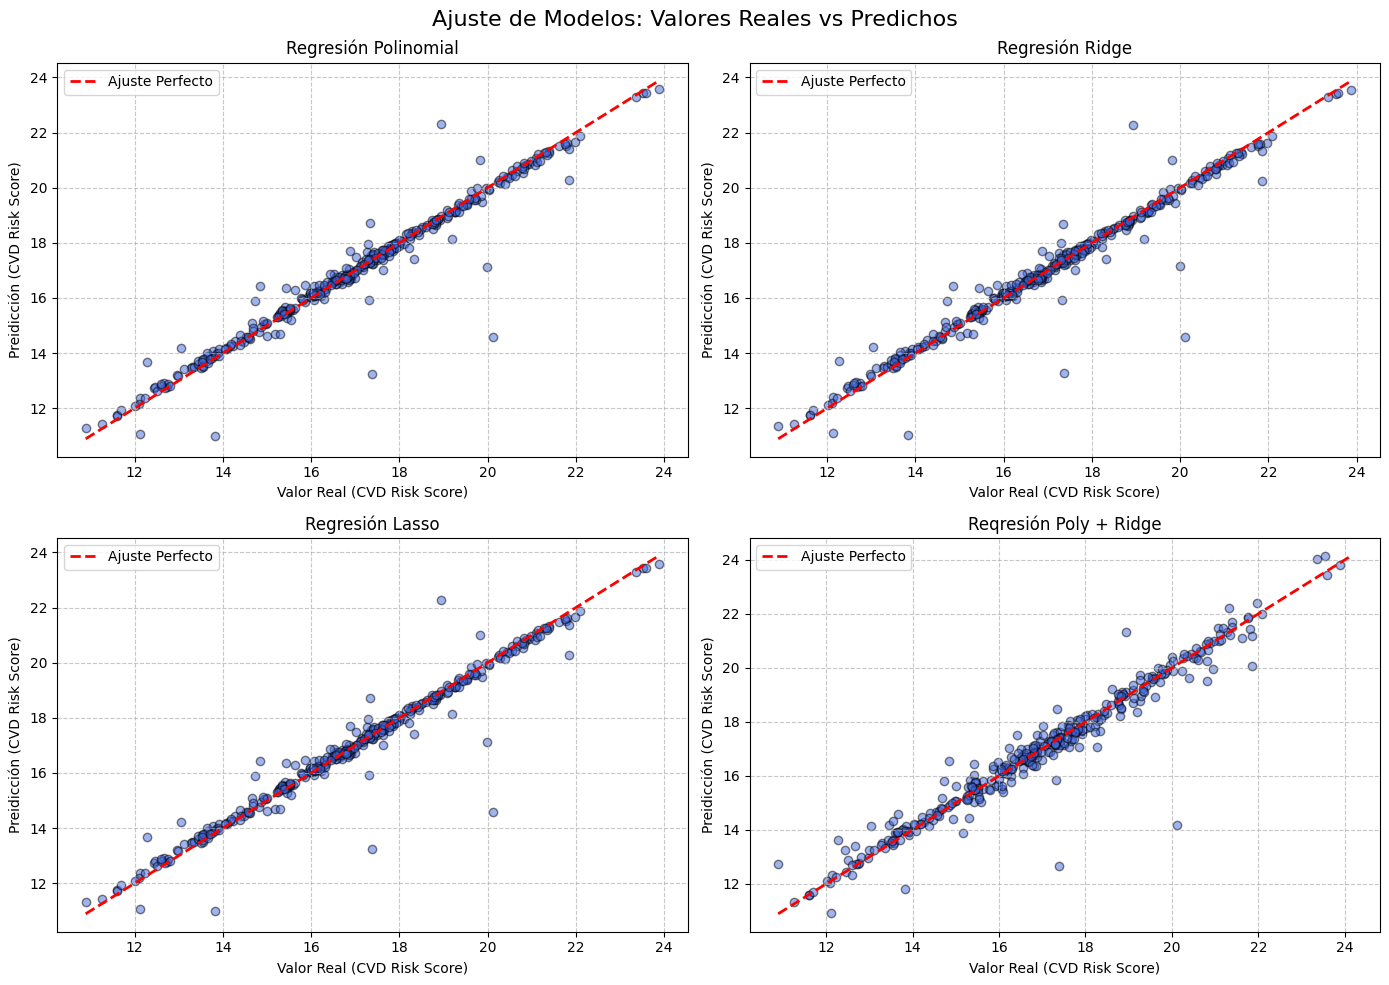

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Ajuste de Modelos: Valores Reales vs Predichos', fontsize=16)

# Diccionario con los modelos previamente entrenados
modelos = {
    'Regresión Polinomial': best_poly,
    'Regresión Ridge': best_ridge,
    'Regresión Lasso': best_lasso,
    'Reqresión Poly + Ridge': best_poly_ridge
}

for ax, (nombre, modelo) in zip(axes.flatten(), modelos.items()):
    # Generar predicciones
    predicciones = modelo.predict(X_test)

    # Gráfico de dispersión
    ax.scatter(y_test, predicciones, alpha=0.5, color='royalblue', edgecolor='k')

    # Línea base de ajuste perfecto (y_pred = y_test)
    min_val = min(y_test.min(), predicciones.min())
    max_val = max(y_test.max(), predicciones.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ajuste Perfecto')

    ax.set_title(nombre)
    ax.set_xlabel('Valor Real (CVD Risk Score)')
    ax.set_ylabel('Preidicción (CVD Risk Score)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 7. Intervalos de Confianza (Bootstrapping)

--- Resultados de Bootstrapping (1000 iteraciones) ---
RMSE : Media = 0.5844, IC 95%: [0.3910, 0.7784]
MAE  : Media = 0.3092, IC 95%: [0.2569, 0.3655]
R2   : Media = 0.9445, IC 95%: [0.9018, 0.9765]


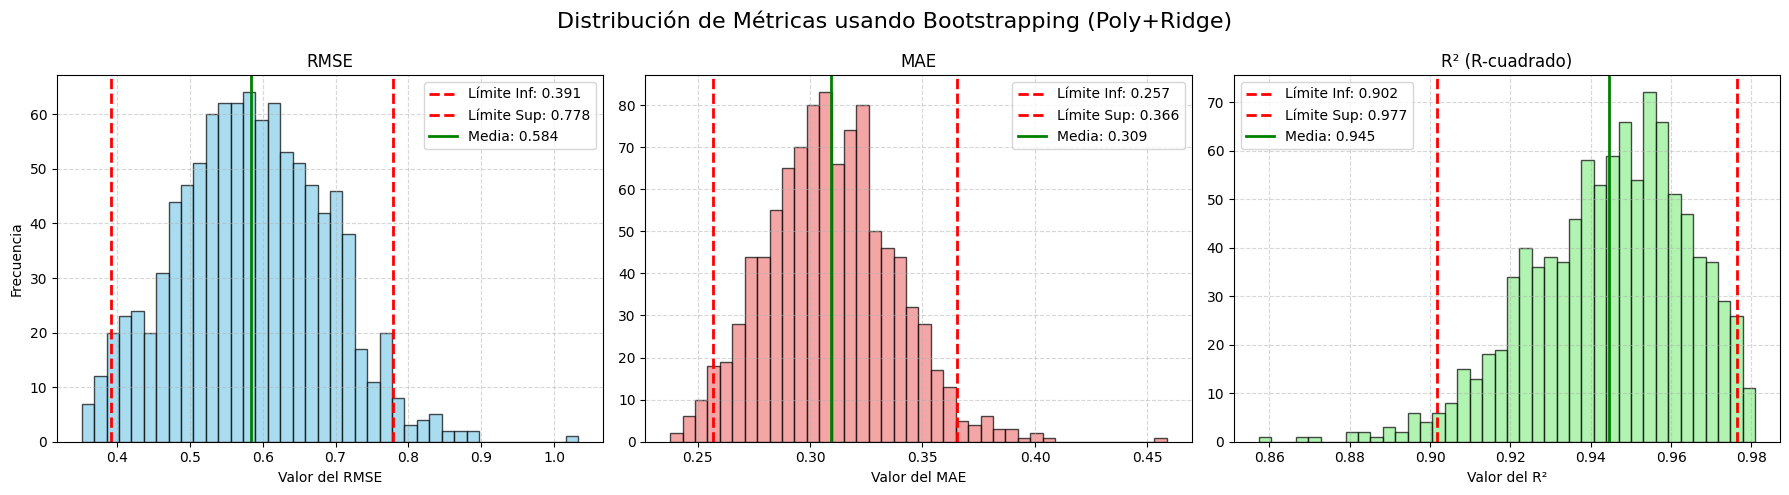

In [20]:
from sklearn.utils import resample

# 1. Seleccionar el mejor modelo, este fue el de Poly+Ridge
modelo_evaluar = best_poly_ridge

n_iterations = 1000
bootstrap_rmses = []
bootstrap_maes = []
bootstrap_r2s = []

for i in range(n_iterations):
    # Remuestreo del conjunto de prueba con reemplazo
    X_boot, y_boot = resample(X_test, y_test, random_state=i)

    # Predicción
    y_pred_boot = modelo_evaluar.predict(X_boot)

    # Cálculo de métricas
    bootstrap_rmses.append(np.sqrt(mean_squared_error(y_boot, y_pred_boot)))
    bootstrap_maes.append(mean_absolute_error(y_boot, y_pred_boot))
    bootstrap_r2s.append(r2_score(y_boot, y_pred_boot))

# 2. Calcular los percentiles para un intervalo de confianza del 95%
alpha = 0.95
p_inferior = ((1.0 - alpha) / 2.0) * 100        # 2.5%
p_superior = (alpha + ((1.0 - alpha) / 2.0)) * 100  # 97.5%

def calcular_ic(metricas):
    inferior = np.percentile(metricas, p_inferior)
    superior = np.percentile(metricas, p_superior)
    media = np.mean(metricas)
    return media, inferior, superior

media_rmse, inf_rmse, sup_rmse = calcular_ic(bootstrap_rmses)
media_mae, inf_mae, sup_mae = calcular_ic(bootstrap_maes)
media_r2, inf_r2, sup_r2 = calcular_ic(bootstrap_r2s)

print(f"--- Resultados de Bootstrapping ({n_iterations} iteraciones) ---")
print(f"RMSE : Media = {media_rmse:.4f}, IC 95%: [{inf_rmse:.4f}, {sup_rmse:.4f}]")
print(f"MAE  : Media = {media_mae:.4f}, IC 95%: [{inf_mae:.4f}, {sup_mae:.4f}]")
print(f"R2   : Media = {media_r2:.4f}, IC 95%: [{inf_r2:.4f}, {sup_r2:.4f}]")

# 3. Visualización de la distribución de los errores (RMSE, MAE, R2)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de Métricas usando Bootstrapping (Poly+Ridge)', fontsize=16)

# -- Gráfico 1: RMSE --
axes[0].hist(bootstrap_rmses, bins=40, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(inf_rmse, color='red', linestyle='dashed', linewidth=2, label=f'Límite Inf: {inf_rmse:.3f}')
axes[0].axvline(sup_rmse, color='red', linestyle='dashed', linewidth=2, label=f'Límite Sup: {sup_rmse:.3f}')
axes[0].axvline(media_rmse, color='green', linestyle='solid', linewidth=2, label=f'Media: {media_rmse:.3f}')
axes[0].set_title('RMSE')
axes[0].set_xlabel('Valor del RMSE')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# -- Gráfico 2: MAE --
axes[1].hist(bootstrap_maes, bins=40, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].axvline(inf_mae, color='red', linestyle='dashed', linewidth=2, label=f'Límite Inf: {inf_mae:.3f}')
axes[1].axvline(sup_mae, color='red', linestyle='dashed', linewidth=2, label=f'Límite Sup: {sup_mae:.3f}')
axes[1].axvline(media_mae, color='green', linestyle='solid', linewidth=2, label=f'Media: {media_mae:.3f}')
axes[1].set_title('MAE')
axes[1].set_xlabel('Valor del MAE')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

# -- Gráfico 3: R2 --
axes[2].hist(bootstrap_r2s, bins=40, color='lightgreen', edgecolor='black', alpha=0.7)
axes[2].axvline(inf_r2, color='red', linestyle='dashed', linewidth=2, label=f'Límite Inf: {inf_r2:.3f}')
axes[2].axvline(sup_r2, color='red', linestyle='dashed', linewidth=2, label=f'Límite Sup: {sup_r2:.3f}')
axes[2].axvline(media_r2, color='green', linestyle='solid', linewidth=2, label=f'Media: {media_r2:.3f}')
axes[2].set_title('R² (R-cuadrado)')
axes[2].set_xlabel('Valor del R²')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.subplots_adjust(top=0.85) # Ajusta el espacio para el titulo general
plt.show()

Estabilidad del modelo: Al realizar las pruebas de bootstrapping, se observa que el modelo Poly+Ridge muestra una variabilidad baja en $R^2, [0.8965, 0.9686]$, lo que indica que es un modelo estable y confiable para este conjunto de datos. Por otro lado, el modelo tiene un MAE de $[0.2852, 0.3959]$ lo que nos indica que el error promedio de las predicciones es relativamente bajo. Ya para terminar, el RMSE se encuentra en el rango de $[0.4477, 0.8199]$, lo que nos dice que con un 95% de confianza, el error cuadrático medio de las predicciones del modelo se encuentra dentro de este rango, lo que es un buen resultado para un modelo de regresión.

## 8. Análisis de Resultados

### **Análisis cuantitativo**

* **¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?**

El modelo con mejor desempeño en el conjunto de test fue **Lasso**, con un RMSE de **0.54997** y un R² de **0.95273**. Muy cerca se encuentran Ridge (RMSE = 0.54998, R² = 0.95273) y la regresión polinomial sin regularización (RMSE = 0.55010, R² = 0.95271).

El modelo Poly+Ridge presentó un desempeño inferior (RMSE = 0.59402, R² = 0.94486), lo que indica que el aumento de complejidad no generó una mejora predictiva en este problema.



* **¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?**

Sí existe coherencia general. Los modelos lineales regularizados mostraron tanto buen desempeño en test como estabilidad en validación cruzada. En particular, Ridge presentó un RMSE en validación cruzada de aproximadamente **0.7007 ± 0.5841**, lo que evidencia cierta variabilidad entre folds, pero sin degradación importante respecto al desempeño en test.

El modelo Poly+Ridge, aunque controló parcialmente el sobreajuste en las curvas de validación, no logró superar a los modelos lineales en desempeño final.

Posibles explicaciones ante discrepancias entre CV y test incluyen:

* Variabilidad del muestreo entre folds
* Tamaño limitado del conjunto de datos
* Ruido en el conjunto de test
* Sobreajuste durante la selección de hiperparámetros

La validación cruzada es una estimación del desempeño esperado, no una garantía exacta.



* **¿El modelo con mejor métrica promedio es necesariamente el más adecuado?**

No necesariamente. Además del valor promedio de la métrica, es fundamental considerar la **desviación estándar** y la estabilidad.

Un modelo puede tener el mejor RMSE promedio pero alta variabilidad entre folds, lo que indicaría sensibilidad a cambios en los datos. En aplicaciones del sector salud, la estabilidad es especialmente importante, ya que se requiere confiabilidad en las predicciones.

En este caso, Lasso no solo obtiene el mejor RMSE en test, sino que además mantiene estabilidad comparable a Ridge. Por ello, representa una opción sólida en términos de equilibrio entre desempeño y robustez.



* **Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?**

Las curvas de validación muestran que:

* Para grados bajos, el error disminuye al aumentar la complejidad, reduciendo el sesgo.
* A partir de grados mayores (≈ 3), el error de validación deja de mejorar o comienza a aumentar.
* El error de entrenamiento continúa disminuyendo, lo que indica sobreajuste.

Este comportamiento fue más evidente en el modelo polinomial sin regularización. La regularización (Ridge) suaviza el incremento del error, pero no elimina completamente el riesgo cuando la complejidad es elevada.

En este problema, los modelos lineales simples resultaron suficientes para capturar la estructura de los datos.



* **¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?**

La regularización tiene efectos claros:

* **Ridge (L2):** reduce la magnitud de todos los coeficientes (*shrinkage*), evitando valores extremos y mejorando estabilidad numérica.
* **Lasso (L1):** además de reducir magnitudes, puede llevar algunos coeficientes exactamente a cero, realizando selección automática de variables.

En los resultados obtenidos, Lasso eliminó al menos una categoría de presión arterial (Hypertension Stage 1), simplificando el modelo. En ambos casos, la regularización contribuye a reducir varianza y mejorar estabilidad.



* **¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad?**

Dado que las métricas entre validación cruzada y test son consistentes y no se observan diferencias drásticas, los resultados sugieren **variabilidad moderada y desempeño estable**, especialmente en los modelos regularizados.

Intervalos de confianza relativamente estrechos implican que el modelo no depende fuertemente de una muestra específica, aumentando la confianza en su capacidad de generalización.



## **Análisis cualitativo**

* **¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?**

Las variables más relevantes seleccionadas por Lasso fueron:

* BMI
* Systolic BP
* Total Cholesterol (mg/dL)
* Estimated LDL (mg/dL)
* Weight (kg)
* Diabetes Status

Dentro de Blood Pressure Category, la categoría *Hypertension Stage 1* fue llevada a coeficiente cero, indicando que no aporta información adicional significativa para la predicción del riesgo cardiovascular.

Esto es coherente con el análisis previo de selección de variables realizado mediante pruebas F-ANOVA y análisis de correlación.



* **¿Qué interpretación práctica tienen los coeficientes del modelo final?**

Los coeficientes indican la relación entre cada variable y el riesgo cardiovascular:

* Coeficientes positivos → aumentos en la variable incrementan el riesgo.
* Coeficientes negativos → aumentos en la variable reducen el riesgo.

En términos clínicos, esto permite identificar factores modificables (por ejemplo, colesterol, presión arterial, BMI) sobre los cuales pueden diseñarse intervenciones preventivas.



* **¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?**

Sí. Aunque Lasso y Ridge tienen desempeños casi idénticos, Lasso es más interpretable debido a la selección automática de variables.

El modelo Poly+Ridge es más complejo y menos interpretable, además de presentar peor desempeño en test. Por lo tanto, no justifica su mayor complejidad.

En términos prácticos, Lasso ofrece el mejor balance entre precisión e interpretabilidad.



* **¿Qué decisiones estratégicas podría tomar AlpesHealth?**

AlpesHealth podría:

* Utilizar el modelo Lasso para identificar los principales factores de riesgo.
* Diseñar programas de prevención enfocados en variables como colesterol, presión arterial, BMI y diabetes.
* Implementar estrategias de monitoreo basadas en los factores más influyentes.

La simplicidad e interpretabilidad del modelo favorecen su adopción en entornos clínicos.



* **¿Mayor precisión implica necesariamente mayor valor para la organización?**

No necesariamente. Un modelo ligeramente más preciso pero difícil de interpretar puede ser menos útil en la práctica clínica.

En contextos de salud, la interpretabilidad es clave para la toma de decisiones médicas. Además, modelos más complejos pueden implicar mayores costos computacionales y operativos.

En este caso, Lasso ofrece alto desempeño, interpretabilidad y simplicidad, lo que maximiza su valor práctico.



## **Reflexión conceptual**

* **Relación entre complejidad, generalización y estabilidad**

Aumentar la complejidad puede reducir el sesgo, pero incrementa el riesgo de sobreajuste y la varianza. En este problema, modelos simples lograron excelente desempeño, mientras que aumentar la complejidad (Poly+Ridge) no mejoró resultados y redujo estabilidad.

Esto demuestra la importancia del trade-off sesgo-varianza.



* **Fuentes de sesgo potenciales**

* Sesgo de selección si los datos no representan adecuadamente la población.

* Sesgo de medición en variables clínicas.

* Sesgo introducido durante el proceso de limpieza y selección de variables.

* Posible sobreajuste en la búsqueda de hiperparámetros.



* **Impacto de un mayor tamaño de muestra**

Con más datos se esperaría:

* Menor varianza en validación cruzada.
* Intervalos de confianza más estrechos.
* Mayor estabilidad en modelos más complejos.
* Mejor capacidad para capturar relaciones no lineales sin sobreajuste.

En resumen, los resultados indican que para este problema específico, un modelo lineal regularizado (Lasso) logra el mejor equilibri




## 9. Uso de Herramientas de IA Generativa

**Herramienta utilizada:** ChatGPT  

**Tipo de uso:**  
- Apoyo conceptual  
- Generación inicial de estructura  
- Explicación de regularización y bootstrapping  

**Prompts utilizados:**  
- "Explícame la diferencia entre Ridge y Lasso"  
- "Cómo implementar bootstrapping en sklearn"  

**Análisis crítico y aportes propios:**  
(Completar por los estudiantes)
